In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from leela_interp.core.effect_study import *
from leela_interp.core.alternative_moves import *
from leela_interp.core.double_branch import *
from leela_interp.core.fifth_move_study import *
from leela_interp.core.general_study import *
from leela_interp.core.ablation_study import AblationStudy
from leela_interp.core.probing_study import ProbingStudy
import subprocess
# Disable FutureWarning
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

/home/dcruz/anaconda3/envs/leela/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#device = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device("cpu")
model = Lc0sight("lc0.onnx", device=device)

Using device: cpu


In [20]:
study = FifthMoveStudy(load_all=False)
study.puzzle_sets['n']['112'].head(30).to_csv("study_puzzles_head30_normal.csv", index=False)

In [27]:
study.puzzle_sets['n']['112'].iloc[0]

PuzzleId                                                                 001w5
FEN                          1rb2rk1/q5P1/4p2p/3p3p/3P1P2/2P5/2QK3P/3R2R1 b...
Moves                                                     f8f7 c2h7 g8h7 g7g8q
Rating                                                                    1073
RatingDeviation                                                             77
Popularity                                                                  91
NbPlays                                                                    189
Themes                       advancedPawn attraction mate mateIn2 middlegam...
GameUrl                                  https://lichess.org/0e1vxAEn/black#57
OpeningTags                                                                NaN
principal_variation                                        [c2h7, g8h7, g7g8q]
full_pv_probs                    [0.7599087357521057, 1.0, 0.9156637191772461]
full_model_moves                                    

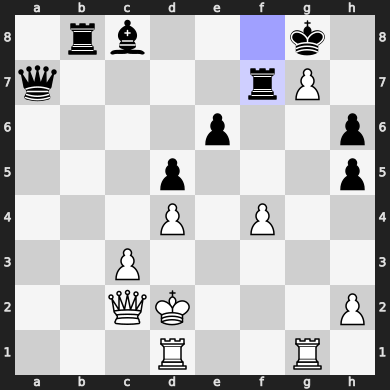

In [26]:
LeelaBoard.from_puzzle(study.puzzle_sets['n']['112'].iloc[0])

# Double branches

In [28]:
from leela_interp.core.double_branch import DoubleBranchStudy

In [33]:
study = DoubleBranchStudy(puzzlename="alternate", load_all=True)

In [34]:
study.find_result_sets(n_examples=1)

In [35]:
study.export_puzzle_set_info_b(tag='b')

In [10]:
study.puzzles.head(10)

,PuzzleId,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,Themes,GameUrl,OpeningTags,...,sparring_full_pv_probs,sparring_full_model_moves,sparring_wdl,branch_1,branch_2,branch_1_probs,branch_2_probs,full_model_moves,full_pv_probs,corrupted_fen
45785,0hgJT,8/b7/P4k2/1N2p3/8/3r3P/R4p1K/8 w - - 0 50,h2g2 d3g3 g2g3 f2f1q,1699,75,81,63,advancedPawn crushing deflection endgame maste...,https://lichess.org/XxLEUNXS#98,NaN,...,"[0.07357572019100189, 0.8615356683731079, 0.55...","[d3d1, g2g3, f2f1q]","[0.014359734021127224, 0.9778732061386108, 0.0...","[d3g3, g2g3, f2f1q]","[d3d1, a2f2, a7f2]","[0.3749047517776489, 0.9617508053779602, 0.964...","[0.3736875057220459, 0.9487216472625732, 0.984...","[d3g3, g2g3, f2f1q]","[0.3749047517776489, 0.9617508053779602, 0.964...",8/b7/P4k2/1N2p3/8/R2r3P/5pK1/8 b - - 1 50
130488,1zJDp,2k2r1r/2p5/5pp1/2pppn2/Q7/4PqB1/PP3P1P/1K1R2R1...,f5g3 a4a8 c8d7 d1d5,1962,76,95,12191,advantage middlegame queensideAttack short,https://lichess.org/GA8Jc3Qv/black#53,NaN,...,"[0.1077740266919136, 1.0, 0.04258124157786369]","[g1g3, c8d7, a8a4]","[0.012248664163053036, 0.9820663928985596, 0.0...","[g1g3, f3e4, a4e4]","[a4a8, c8d7, d1d5]","[0.3392634689807892, 0.9276943802833557, 0.977...","[0.30147477984428406, 1.0, 0.7932175397872925]","[g1g3, f3e4, a4e4]","[0.30147477984428406, 1.0, 0.7932175397872925]",2k2r1r/2p5/5pp1/1Rppp3/Q7/4Pqn1/PP3P1P/1K4R1 w...
151814,2JetC,r5k1/5p1p/6p1/1B3q2/P2R1n1P/2B2P2/KP3P2/4R3 b ...,f5b5 d4d8 a8d8 a4b5,1915,75,78,75,advantage endgame short,https://lichess.org/aDeJsYC1/black#65,NaN,...,"[0.003927054814994335, 0.9542078375816345, 0.8...","[d4f4, a8d8, a4b5]","[0.004065464250743389, 0.9922393560409546, 0.0...","[d4d8, a8d8, a4b5]","[d4f4, a8a4, f4a4]","[0.5213490724563599, 0.9653069376945496, 0.935...","[0.37743544578552246, 0.9058992266654968, 0.98...","[d4d8, a8d8, a4b5]","[0.5213490724563599, 0.9653069376945496, 0.935...",r1k5/5p1p/6p1/1q6/P2R1n1P/2B2P2/KP3P2/4R3 w - ...
247984,3mLih,3Q4/p4ppk/2N1r3/6rp/1P2p2q/7P/P5P1/2R2RK1 w - ...,f1f5 g5g2 g1g2 e6g6,2356,97,90,1181,attraction crushing middlegame sacrifice short,https://lichess.org/MEcrM7n2#62,NaN,...,"[0.032271627336740494, 0.7729446887969971, 0.4...","[g5f5, g1g2, e6g6]","[0.0027438101824373007, 0.9955427050590515, 0....","[e6c6, d8g5, h4g5]","[g5g2, g1g2, e6g6]","[0.5575438737869263, 0.7567914128303528, 0.938...","[0.30185580253601074, 0.9773067831993103, 0.93...","[e6c6, d8g5, h4g5]","[0.30185580253601074, 0.9773067831993103, 0.93...",3Q4/p4ppk/2N1r3/5Rrp/1P2p2q/7P/P5P1/2RK4 b - -...
351300,5MHT9,8/4p3/1p1pPbpk/pPpP1r1p/P1P1KP1P/5PR1/8/4B3 b ...,f6h4 g3g6 h6g6 e1h4,1010,83,94,258,crushing discoveredAttack endgame short,https://lichess.org/5LkjT71t/black#109,NaN,...,"[0.017505118623375893, 0.9499063491821289, 0.7...","[g3g1, h6g6, e1h4]","[0.01847837120294571, 0.9530161023139954, 0.02...","[g3g6, h6g6, e1h4]","[g3g1, h4e1, g1e1]","[0.6266805529594421, 0.8698269724845886, 0.930...","[0.3034615218639374, 0.8903855681419373, 0.973...","[g3g6, h6g6, e1h4]","[0.6266805529594421, 0.8698269724845886, 0.930...",8/4p3/1p1pP1pk/pPpP1r1p/P1P1KP2/5PR1/8/4Bb2 w ...
543615,8I4mT,1r3rk1/pb3pQp/1p6/2p1R3/7P/1P6/PBPq1PP1/4R1K1 ...,g8g7 e5g5 g7h6 b2g7,1820,75,95,906,middlegame,https://lichess.org/1AMVO10l/black#37,NaN,...,"[0.12031206488609314, 1.0, 0.541566014289856]","[e1e2, g7h6, b2g7]","[0.0038786958903074265, 0.9826149940490723, 0....","[e5g5, g7h6, b2g7]","[e5d5, d2d4, b2d4]","[0.455334335565567, 1.0, 0.8661252856254578]","[0.41387954354286194, 0.7251966595649719, 0.74...","[e5g5, g7h6, b2g7]","[0.455334335565567, 1.0, 0.8661252856254578]",5r2/pb3pkp/1p6/2p1R3/7P/1Pr5/PBPq1PP1/4R1K1 w ...
594957,94W88,5qk1/2p3pp/p1Q5/7b/3P4/2P1RN1P/r7/4K3 b - - 1 32,h5f3 c6c4 g8h8 c4a2,2015,77,92,4375,advantage endgame fork short,https://lichess.org/4Bjnl96v/black#63,NaN,...,"[0.040972236543893814, 0.6797309517860413, 0.7...","[e3f3, g8h8, c4a2]","[0.0014351039426401258, 0.994997501373291, 0.0...","[c6c4, g8h8, c4a2]","[c6e6, f8f7, e6c8]","[0.45929232239

In [36]:
import pandas as pd
study.puzzles.to_csv("study_puzzles_head_all_alternate.csv", index=False)

123425 4 4


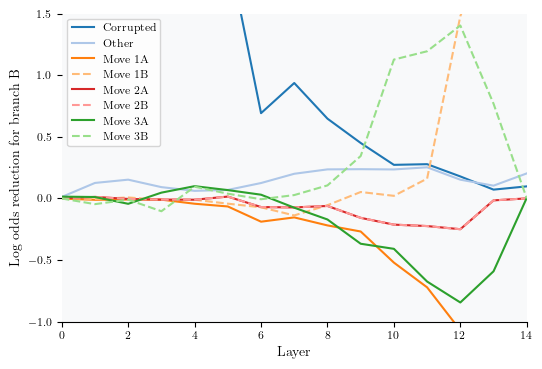

In [8]:
study.plot_residual_effects('b', '123425', b=True, plot_std=False, plot_ci=False)

123425 4 4


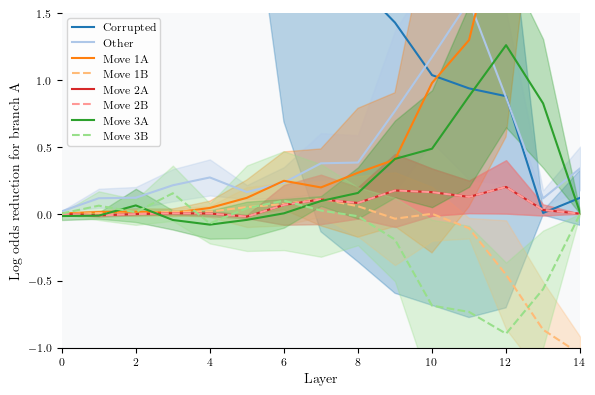

In [17]:
study.plot_residual_effects('b', '123425', b=False, filename="paper_residual_effects_123425", plot_std=True, plot_ci=False)

123425 4 4
123425 4 4


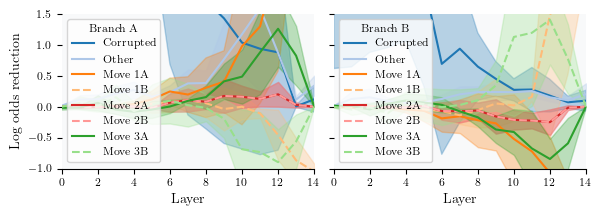

In [18]:
study.plot_residual_effects_grid_A_vs_B('b', ['123425'], filename="paper_residual_effects_123425_a_vs_b", plot_std=True, plot_ci=False)

## Alternate dataset

In [19]:
study = DoubleBranchStudy(puzzlename="alternate", load_all=True)

In [20]:
study.find_result_sets(n_examples=1)
study.export_puzzle_set_info_b(tag='b')

123425 71 71
123425 71 71


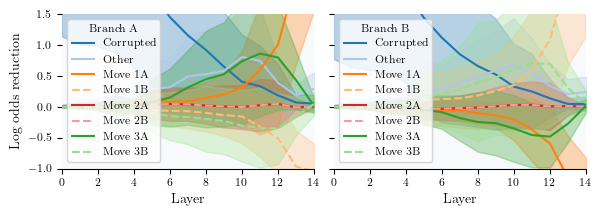

In [21]:
study.plot_residual_effects_grid_A_vs_B('b', ['123425'], plot_std=True, plot_ci=False)

112334 36 36
112334 36 36


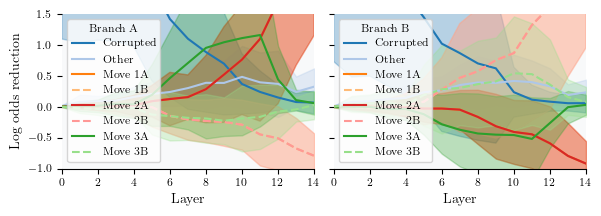

123425 71 71
123425 71 71


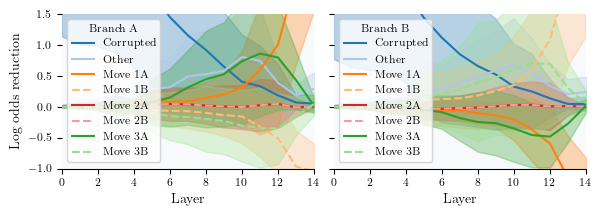

In [22]:
possibilities = study.get_possibility_list('b', lengths=[3])
filtered_possibilities = [p for p in possibilities 
                        if p[1] != p[2] and p[4] != p[5]][:4]
filtered_possibilities = ['112334', '123425']
for possibility in filtered_possibilities:
    study.plot_residual_effects_grid_A_vs_B('b', [possibility], filename=f"paper_residual_effects_{possibility}_a_vs_b", plot_std=True, plot_ci=False)

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

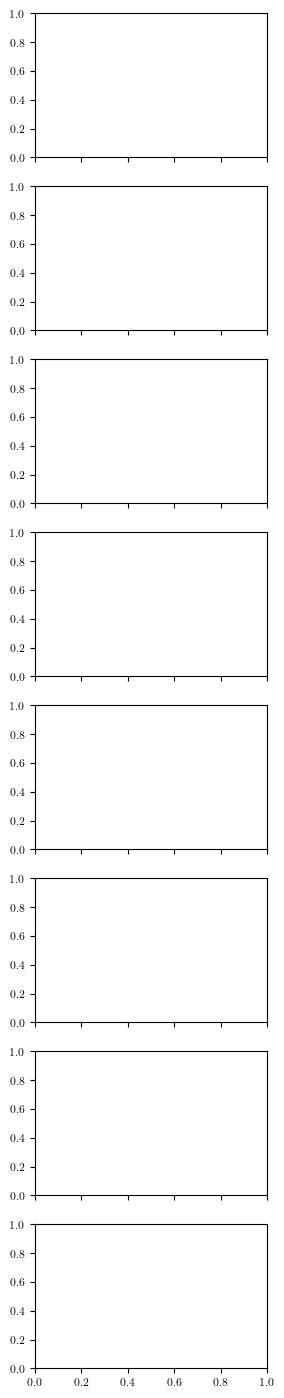

In [23]:
possibilities = study.get_possibility_list('b', lengths=[3])
filtered_possibilities = [p for p in possibilities 
                        if p[1] != p[2] and p[4] != p[5]][:4]
study.plot_residual_effects_grid_A_vs_B('b', filtered_possibilities, n_cols=1, filename="paper_residual_effects_a_vs_b", plot_std=True, plot_ci=False)

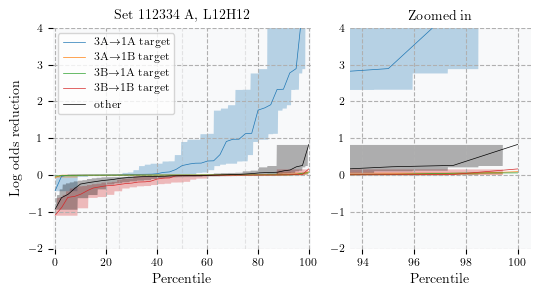

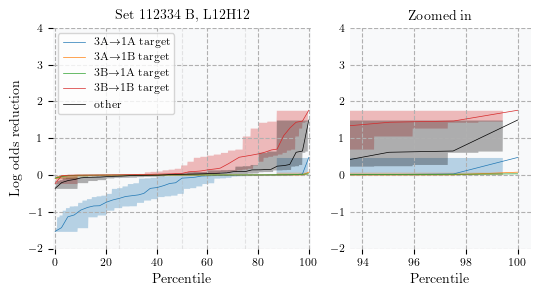

In [140]:
# Create an AblationStudy instance with the specified folder
ablation_study = AblationStudy(folder_name='L12H12_alternate_b_112334', double_branch=True, b=False)
ablation_study.plot_ablation_effects(double_branch=True, puzzle_set='112334 A', LH='L12H12', filename="paper_ablation_effects_112334_alternate_a")
ablation_study = AblationStudy(folder_name='L12H12_alternate_b_112334', double_branch=True, b=True)
ablation_study.plot_ablation_effects(double_branch=True, puzzle_set='112334 B', LH='L12H12', filename="paper_ablation_effects_112334_alternate_b")

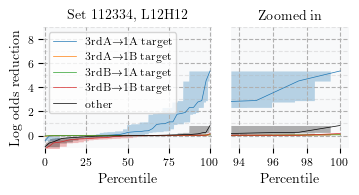

In [123]:
ablation_study = AblationStudy(folder_name="", double_branch=True, b=False)
ablation_configs = [
    ('L12H12', "112334"),
]
ablation_study.plot_ablation_effects_grid(ablation_configs, n_cols=1, tag='alternate_b', double_branch=True)

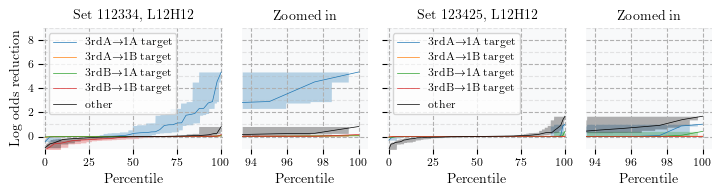

In [122]:
ablation_study = AblationStudy(folder_name="", double_branch=True, b=True)
ablation_configs = [
    ('L12H12', "112334"),
    ('L12H12', "123425"),
]
ablation_study.plot_ablation_effects_grid(ablation_configs, n_cols=2, tag='alternate_b', double_branch=True)